In [ ]:
# Import pandas for handling datasets
import pandas as pd

# Import numpy for mathematical operations
import numpy as np

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import LabelEncoder and StandardScaler
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Import train_test_split
from sklearn.model_selection import train_test_split

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Dataset URL
url = "https://github.com/ybifoundation/Dataset/raw/main/Fish.csv"

# Read the dataset
df = pd.read_csv(url)

# Display first 5 rows
df.head()

,Category,Species,Weight,Height,Width,Length1,Length2,Length3
0,1,Bream,242.0,11.5200,4.0200,23.2,25.4,30.0
1,1,Bream,290.0,12.4800,4.3056,24.0,26.3,31.2
2,1,Bream,340.0,12.3778,4.6961,23.9,26.5,31.1
3,1,Bream,363.0,12.7300,4.4555,26.3,29.0,33.5
4,1,Bream,430.0,12.4440,5.1340,26.5,29.0,34.0


In [ ]:
# Display the number of rows and columns
print(df.shape)

# Display the column names
print(df.columns)

# Display information about the dataset
print(df.info())

# Check for missing values
print(df.isnull().sum())

# Display statistical summary
print(df.describe())

(159, 8)
Index(['Category', 'Species', 'Weight', 'Height', 'Width', 'Length1',
       'Length2', 'Length3'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  159 non-null    int64  
 1   Species   159 non-null    object 
 2   Weight    159 non-null    float64
 3   Height    159 non-null    float64
 4   Width     159 non-null    float64
 5   Length1   159 non-null    float64
 6   Length2   159 non-null    float64
 7   Length3   159 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 10.1+ KB
None
Category    0
Species     0
Weight      0
Height      0
Width       0
Length1     0
Length2     0
Length3     0
dtype: int64
         Category       Weight      Height       Width     Length1  \
count  159.000000   159.000000  159.000000  159.000000  159.000000   
mean     3.264151   398.326415    8.970994

In [ ]:
# Create a LabelEncoder object
encoder = LabelEncoder()

# Convert Species names into numerical values
df["Species"] = encoder.fit_transform(df["Species"])

# Display the updated dataset
df.head()

,Category,Species,Weight,Height,Width,Length1,Length2,Length3
0,1,0,242.0,11.5200,4.0200,23.2,25.4,30.0
1,1,0,290.0,12.4800,4.3056,24.0,26.3,31.2
2,1,0,340.0,12.3778,4.6961,23.9,26.5,31.1
3,1,0,363.0,12.7300,4.4555,26.3,29.0,33.5
4,1,0,430.0,12.4440,5.1340,26.5,29.0,34.0


In [ ]:
# Select all columns except Weight as input features
X = df.drop("Weight", axis=1)

# Select Weight as the target variable
y = df["Weight"]

# Display input features
print(X.head())

# Display target values
print(y.head())

   Category  Species   Height   Width  Length1  Length2  Length3
0         1        0  11.5200  4.0200     23.2     25.4     30.0
1         1        0  12.4800  4.3056     24.0     26.3     31.2
2         1        0  12.3778  4.6961     23.9     26.5     31.1
3         1        0  12.7300  4.4555     26.3     29.0     33.5
4         1        0  12.4440  5.1340     26.5     29.0     34.0
0    242.0
1    290.0
2    340.0
3    363.0
4    430.0
Name: Weight, dtype: float64


In [ ]:
# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shape of training and testing datasets
print(X_train.shape)
print(X_test.shape)

(127, 7)
(32, 7)


In [ ]:
# Create a StandardScaler object
scaler = StandardScaler()

# Scale the training data
X_train = scaler.fit_transform(X_train)

# Scale the testing data
X_test = scaler.transform(X_test)

# Display the shape of the scaled data
print(X_train.shape)
print(X_test.shape)

(127, 7)
(32, 7)


In [ ]:
# Create a Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Display the intercept of the model
print(model.intercept_)

# Display the coefficients of each feature
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

386.7944881889766
    Feature  Coefficient
0  Category    23.561849
1   Species    23.561849
2    Height   166.341972
3     Width    -0.480826
4   Length1    30.167874
5   Length2   712.558565
6   Length3  -513.151817


In [ ]:
# Predict fish weights using the testing data
y_pred = model.predict(X_test)

# Compare actual and predicted values
result = pd.DataFrame({
    "Actual Weight": y_test,
    "Predicted Weight": y_pred
})

# Display the first 10 predictions
print(result.head(10))

     Actual Weight  Predicted Weight
78            78.0         76.852435
155           13.4       -122.873152
128          200.0        383.344496
55           270.0        420.944718
94           150.0        149.914824
29          1000.0        828.547139
147            7.0       -192.515578
51           180.0        289.991264
98           188.0        248.953049
141         1250.0       1135.746471


In [ ]:
# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

# Calculate R² Score
r2 = r2_score(y_test, y_pred)

# Display the evaluation results
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 97.297913053304
MSE : 13727.81655300652
RMSE : 117.16576527726228
R2 Score : 0.9034878699241473


In [ ]:
# Display the feature names
print(X.columns)

# Display the total number of input features
print(len(X.columns))

# Create sample fish data
sample = pd.DataFrame({
    "Category": [0],
    "Species": [0],
    "Height": [12.48],
    "Width": [4.30],
    "Length1": [24.0],
    "Length2": [26.3],
    "Length3": [31.2]
})

# Scale the sample data
sample_scaled = scaler.transform(sample)

# Predict the fish weight
prediction = model.predict(sample_scaled)

# Display the predicted fish weight
print("Predicted Fish Weight:", prediction[0], "grams")

Index(['Category', 'Species', 'Height', 'Width', 'Length1', 'Length2',
       'Length3'],
      dtype='object')
7
Predicted Fish Weight: 308.6755859840364 grams


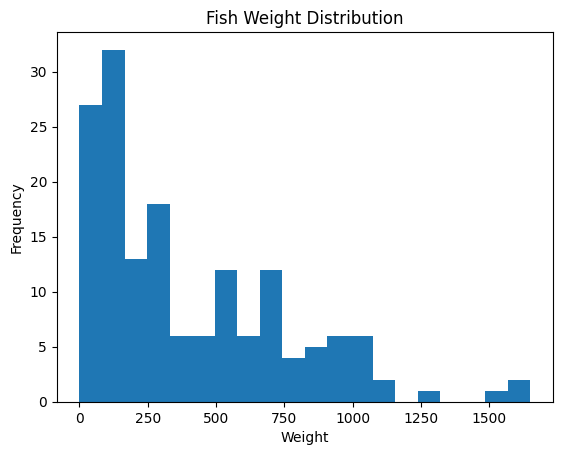

In [ ]:
# Create a histogram of fish weights
plt.hist(df["Weight"], bins=20)

# Add chart title
plt.title("Fish Weight Distribution")

# Label the x-axis
plt.xlabel("Weight")

# Label the y-axis
plt.ylabel("Frequency")

# Display the graph
plt.show()

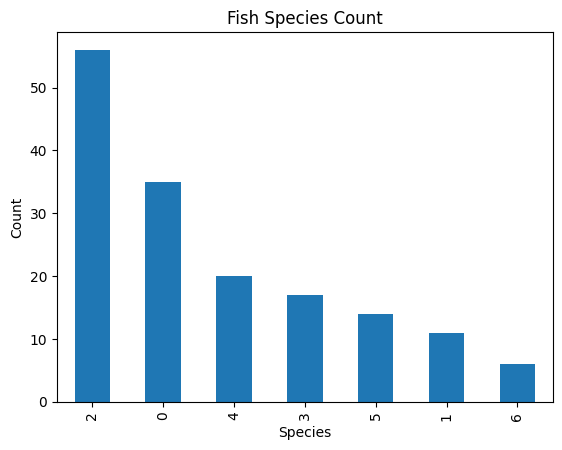

In [ ]:
# Count the number of fish in each species
df["Species"].value_counts().plot(kind="bar")

# Add chart title
plt.title("Fish Species Count")

# Label the x-axis
plt.xlabel("Species")

# Label the y-axis
plt.ylabel("Count")

# Display the graph
plt.show()

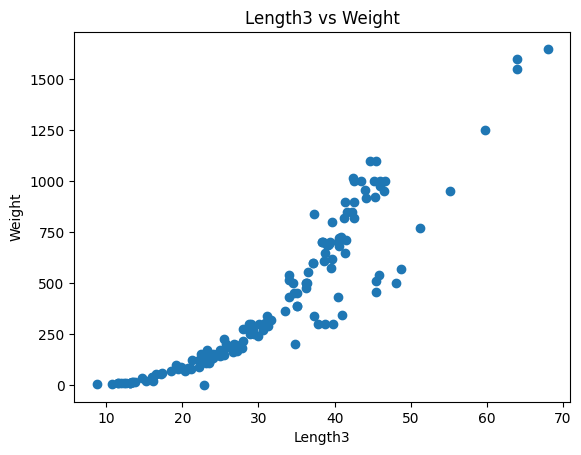

In [ ]:
# Create a scatter plot between Length3 and Weight
plt.scatter(df["Length3"], df["Weight"])

# Add chart title
plt.title("Length3 vs Weight")

# Label the x-axis
plt.xlabel("Length3")

# Label the y-axis
plt.ylabel("Weight")

# Display the graph
plt.show()


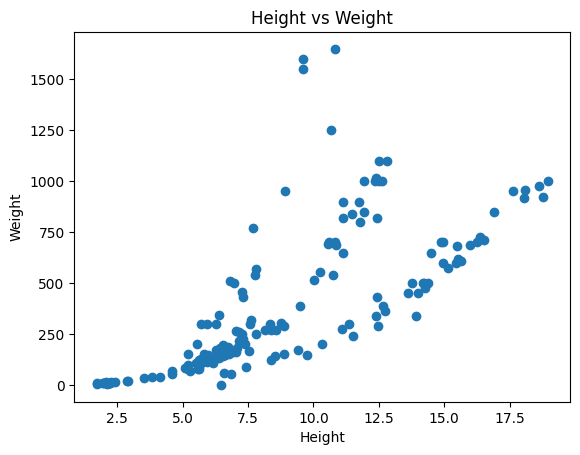

In [ ]:
# Create a scatter plot between Height and Weight
plt.scatter(df["Height"], df["Weight"])

# Add chart title
plt.title("Height vs Weight")

# Label the x-axis
plt.xlabel("Height")

# Label the y-axis
plt.ylabel("Weight")

# Display the graph
plt.show()

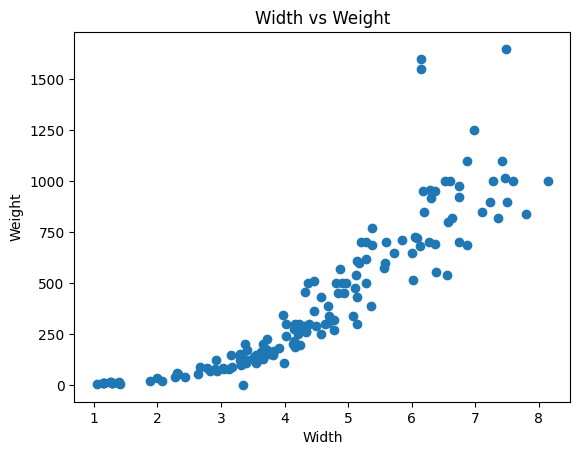

In [ ]:
# Create a scatter plot between Width and Weight
plt.scatter(df["Width"], df["Weight"])

# Add chart title
plt.title("Width vs Weight")

# Label the x-axis
plt.xlabel("Width")

# Label the y-axis
plt.ylabel("Weight")

# Display the graph
plt.show()

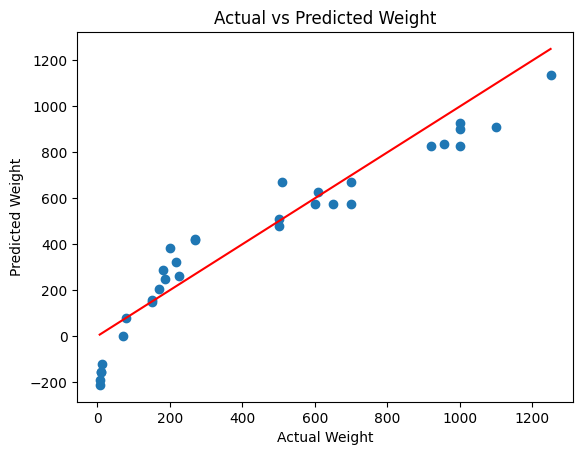

In [ ]:
# Create a scatter plot of actual and predicted weights
plt.scatter(y_test, y_pred)

# Draw a reference line for perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

# Add chart title
plt.title("Actual vs Predicted Weight")

# Label the x-axis
plt.xlabel("Actual Weight")

# Label the y-axis
plt.ylabel("Predicted Weight")

# Display the graph
plt.show()